## Project Overview
- **Objective**: Predict customer **CLV (Customer Lifetime Value)** to segment customers for targeted marketing strategies.
- **Approach**: 
   1. Data preprocessing including handling missing values and scaling.
   2. Feature Engineering using RFM (Recency, Frequency, Monetary) metrics.
   3. Model selection using **Random Forest Regressor**.
   4. Hyperparameter tuning using **RandomizedSearchCV** to find optimal model parameters.
   5. Evaluation metrics (RMSE, R²) showed **888.65 RMSE** and **0.6159 R²**, indicating a decent predictive model.

In [1]:
# Import necessary libraries
import pandas as pd

# Load the dataset with both sheets
file_path = '/kaggle/input/online-retail-ii/online_retail_II.xlsx'  

# Load both sheets into separate dataframes
df_2009_2010 = pd.read_excel(file_path, sheet_name='Year 2009-2010')
df_2010_2011 = pd.read_excel(file_path, sheet_name='Year 2010-2011')

# Display the first few rows of each sheet
print("2009-2010 Data:")
display(df_2009_2010.head())

print("\n2010-2011 Data:")
display(df_2010_2011.head())

2009-2010 Data:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



2010-2011 Data:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Conducting EDA

In [2]:
import numpy as np

# Combine both datasets into one
df = pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)

print("Basic Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB

Descriptive Statistics:
           Quantity                    InvoiceDate         Price  \
count  1.067371e+06                        1067371  1.067371e+06   
mean   9.938898e+00  2011-01-02 21:13:55.394028544  4.649388e+00   
min   -8.099500e+04            2009-12-01 07:45:00 -5.3

In [3]:
# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing values in each column:")
print(missing_values[missing_values > 0])

duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Clean the data
# Optionally, confirm which missing values to drop or handle before proceeding
# For demonstration, let's drop rows with missing values
df_cleaned = df.dropna()

# Remove duplicates
df_cleaned = df_cleaned.drop_duplicates()

# Convert date columns to datetime format
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])

# Confirm the data cleaning
print("\nData after cleaning:")
print(df_cleaned.info())


Missing values in each column:
Description      4382
Customer ID    243007
dtype: int64

Number of duplicate rows: 34335

Data after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 797885 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      797885 non-null  object        
 1   StockCode    797885 non-null  object        
 2   Description  797885 non-null  object        
 3   Quantity     797885 non-null  int64         
 4   InvoiceDate  797885 non-null  datetime64[ns]
 5   Price        797885 non-null  float64       
 6   Customer ID  797885 non-null  float64       
 7   Country      797885 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 54.8+ MB
None


In [4]:
# Define a function to identify and remove outliers using the Interquartile Range (IQR) method
def remove_outliers_iqr(df, columns):
    outliers = pd.DataFrame()  # Create a DataFrame to store outliers

    for col in columns:
        if df[col].dtype in ['float64', 'int64']:  # Check if the column is numeric
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            
            # Define the lower and upper bounds for outliers
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Identify outliers
            outliers_col = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
            outliers = pd.concat([outliers, outliers_col])  # Append outliers to the DataFrame
            
            # Filter the DataFrame to remove outliers
            df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
    return df, outliers

# Specify the numerical columns you want to check for outliers
numerical_columns = ['Quantity', 'Price']  # Adjusted for your dataset

# Identify and remove outliers from the cleaned DataFrame
df_cleaned_no_outliers, outliers = remove_outliers_iqr(df_cleaned, numerical_columns)

# Print outliers before removal
print("\nOutliers before removal:")
print(outliers)

# Confirm the data after removing outliers
print("\nData after removing outliers:")
print(df_cleaned_no_outliers.info())



Outliers before removal:
        Invoice StockCode                      Description  Quantity  \
3        489434     22041     RECORD FRAME 7" SINGLE SIZE         48   
54       489438     21329          DINOSAURS  WRITING SET         28   
55       489438     21252   SET OF MEADOW  FLOWER STICKERS        30   
56       489438     21100   CHARLIE AND LOLA CHARLOTTE BAG        30   
57       489438     21033  JUMBO BAG CHARLIE AND LOLA TOYS        30   
...         ...       ...                              ...       ...   
1067247  581578     22622   BOX OF VINTAGE ALPHABET BLOCKS         6   
1067292  581579     22941     CHRISTMAS LIGHTS 10 REINDEER         4   
1067313  581580     22894    TABLECLOTH RED APPLES DESIGN          2   
1067353  581586     21217    RED RETROSPOT ROUND CAKE TINS        24   
1067370  581587      POST                          POSTAGE         1   

                InvoiceDate  Price  Customer ID         Country  
3       2009-12-01 07:45:00   2.10      130

### Let's analyze the outliers further just in case 

Investigating Characteristics of Outliers by filtering the outliers into a separate DataFrame and then summarizing their characteristics:

In [5]:
# Calculate IQR for Quantity
Q1_quantity = df_cleaned['Quantity'].quantile(0.25)
Q3_quantity = df_cleaned['Quantity'].quantile(0.75)
IQR_quantity = Q3_quantity - Q1_quantity
upper_limit_quantity = Q3_quantity + 1.5 * IQR_quantity

# Calculate IQR for Price
Q1_price = df_cleaned['Price'].quantile(0.25)
Q3_price = df_cleaned['Price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
upper_limit_price = Q3_price + 1.5 * IQR_price

# Print the upper limits
print(f"Upper limit for Quantity: {upper_limit_quantity}")
print(f"Upper limit for Price: {upper_limit_price}")


Upper limit for Quantity: 27.0
Upper limit for Price: 7.5


**Visualizing the outliers**

**Histogram:** We’ll see the frequency distribution of Quantity and Price. The red dashed line indicates the upper limit for outliers, helping us visually identify where the outliers fall in relation to the main distribution.

**Scatter Plot:** This plot will show how Quantity and Price relate to each other. Outliers will be marked in red, making it easy to identify them against the overall distribution.

**But first** let's review some descriptive statistics to understand the range and distribution of the Quantity and Price columns

In [6]:
# Descriptive statistics for Quantity and Price
print("Descriptive statistics for Quantity:")
print(df_cleaned['Quantity'].describe())

print("\nDescriptive statistics for Price:")
print(df_cleaned['Price'].describe())

Descriptive statistics for Quantity:
count    797885.000000
mean         12.602980
std         191.670371
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

Descriptive statistics for Price:
count    797885.000000
mean          3.702732
std          71.392549
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max       38970.000000
Name: Price, dtype: float64


The descriptive statistics for both `Quantity` and `Price` indicate some significant issues, particularly the presence of negative values in `Quantity` and a wide range in `Price`.

##### Observations

1. **Quantity**:
   - **Minimum Value**: -80,995, which is problematic since quantity cannot be negative.
   - **Maximum Value**: 80,995, indicating some extreme outlier values.
   - **Mean vs. Max**: The mean of 12.60 compared to the max suggests a lot of high outlier values skewing the distribution.

2. **Price**:
   - **Minimum Value**: 0, which means there are transactions with no cost. This could also indicate an issue, especially if you are modeling CLV.
   - **Maximum Value**: 38,970 suggests there are very high-priced items that may be outliers.


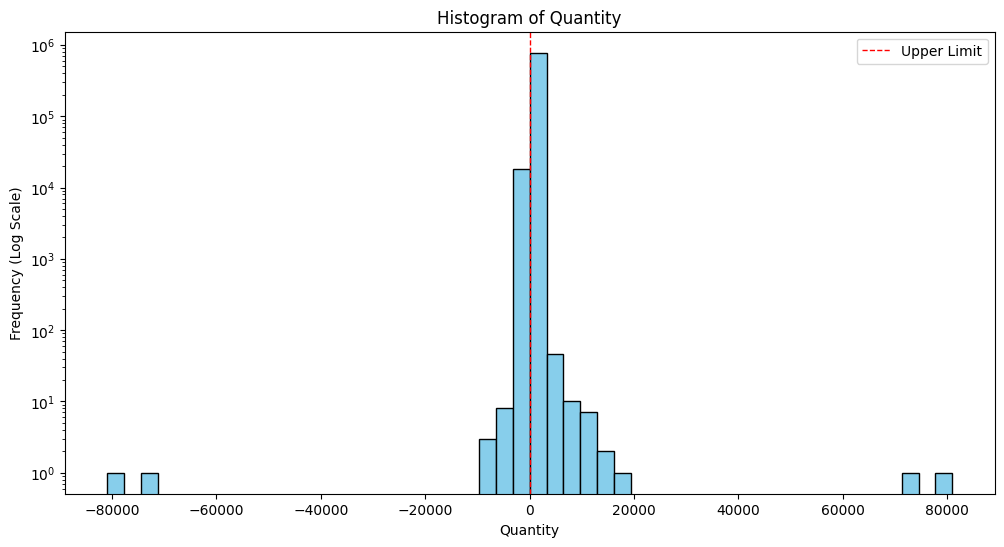

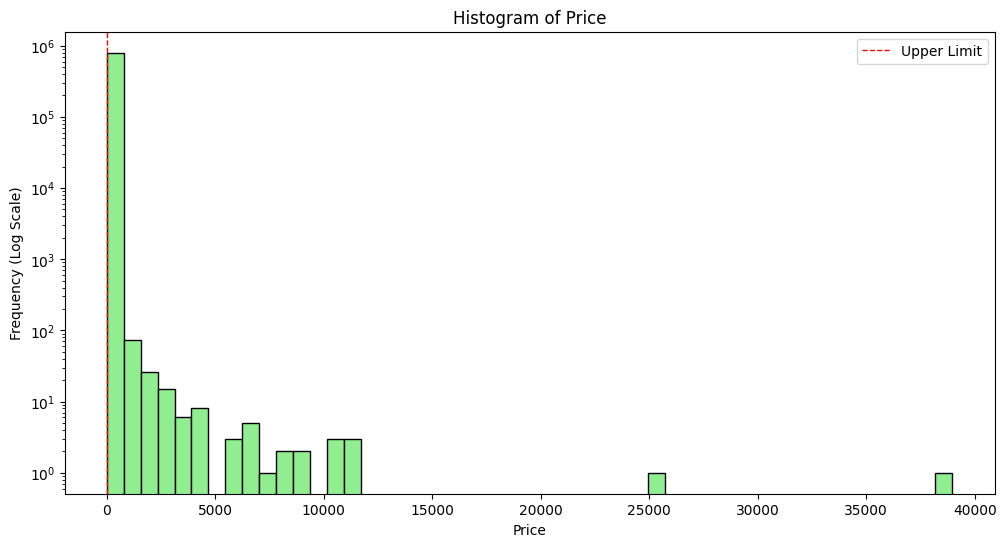

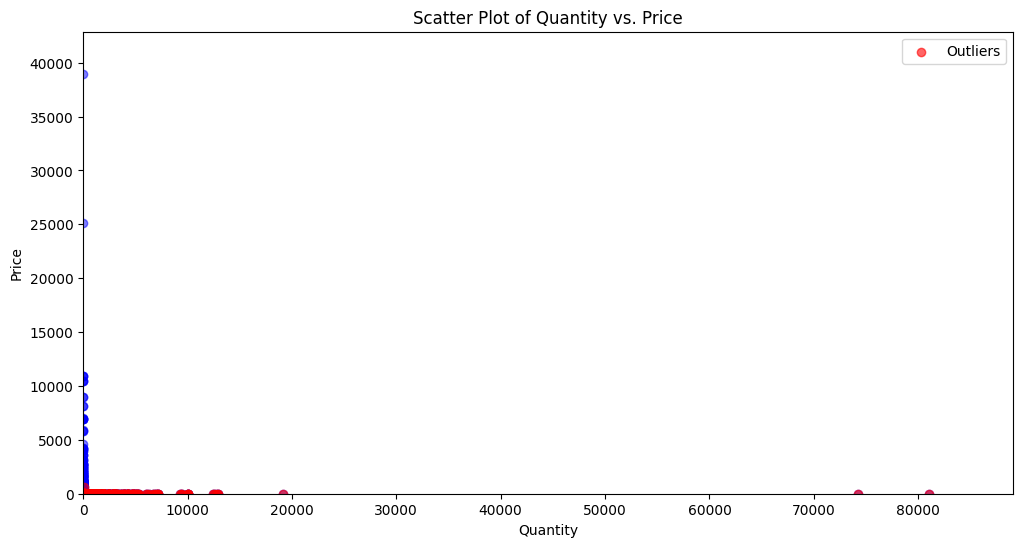

In [7]:
import matplotlib.pyplot as plt

# Identify outliers
outliers_quantity = df_cleaned[df_cleaned['Quantity'] > upper_limit_quantity]
outliers_price = df_cleaned[df_cleaned['Price'] > upper_limit_price]

# Histogram for Quantity with log scale
plt.figure(figsize=(12, 6))
plt.hist(df_cleaned['Quantity'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(x=upper_limit_quantity, color='red', linestyle='dashed', linewidth=1, label='Upper Limit')
plt.title('Histogram of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency (Log Scale)')
plt.yscale('log')  # Use logarithmic scale for y-axis
plt.legend()
plt.show()

# Histogram for Price with log scale
plt.figure(figsize=(12, 6))
plt.hist(df_cleaned['Price'], bins=50, color='lightgreen', edgecolor='black')
plt.axvline(x=upper_limit_price, color='red', linestyle='dashed', linewidth=1, label='Upper Limit')
plt.title('Histogram of Price')
plt.xlabel('Price')
plt.ylabel('Frequency (Log Scale)')
plt.yscale('log')  # Use logarithmic scale for y-axis
plt.legend()
plt.show()

# Scatter plot for Quantity vs. Price with adjusted limits
plt.figure(figsize=(12, 6))
plt.scatter(df_cleaned['Quantity'], df_cleaned['Price'], alpha=0.5, color='blue')
plt.scatter(outliers_quantity['Quantity'], outliers_quantity['Price'], color='red', label='Outliers', alpha=0.6)
plt.title('Scatter Plot of Quantity vs. Price')
plt.xlabel('Quantity')
plt.ylabel('Price')
plt.xlim(0, df_cleaned['Quantity'].max() * 1.1)  # Set limits to max value with some margin
plt.ylim(0, df_cleaned['Price'].max() * 1.1)      # Set limits to max value with some margin
plt.legend()
plt.show()

Looks like we are not missing much if we choose to not include the outliers in our analysis

## Feature Engineering

Let's proceed with creating the RFM metrics using the `df_cleaned_no_outliers` dataframe.

#### 1. Creating RFM Metrics

1. **Recency**: Calculate the number of days since the last purchase for each customer.
2. **Frequency**: Count the number of purchases for each customer.
3. **Monetary**: Calculate the total spending for each customer.

#### Explanation:
- **Recency**: For each customer, the code calculates the difference between the snapshot date and the last purchase date.
- **Frequency**: Counts the number of invoices (purchases) for each customer.
- **Monetary**: Sums the total amount spent (Price) by each customer.

In [8]:
# We will use the df_cleaned_no_outliers dataframe

# Create a snapshot date (the date we want to calculate recency from)
snapshot_date = df_cleaned_no_outliers['InvoiceDate'].max() + pd.DateOffset(days=1)

# Create RFM metrics
rfm_df = df_cleaned_no_outliers.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Invoice': 'count',  # Frequency
    'Price': 'sum'       # Monetary
}).reset_index()

# Rename the columns
rfm_df.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

# Display the RFM metrics
print(rfm_df.head())

   Customer ID  Recency  Frequency  Monetary
0      12346.0      431         38    222.85
1      12347.0        2        205    450.54
2      12348.0      249         26     18.29
3      12349.0       19        142    373.84
4      12350.0      310         16     25.30


The RFM metrics appear to be reasonable and typical for a retail dataset. Here's a quick analysis of each metric:

- **Recency**: Values like 2 (very recent) and 431 (older) are common, indicating that some customers have made recent purchases while others have not purchased in a long time.
- **Frequency**: The range of frequencies (from 16 to 205 purchases) suggests a diverse customer base, with some customers being frequent buyers and others making fewer purchases.
- **Monetary**: The monetary values range from 18.29 to 450.54, indicating different spending behaviors among customers.

#### 2. Creating Customer Segmentation

1. **Calculate RFM Scores**: Assign scores for Recency, Frequency, and Monetary values based on quantiles.
2. **Combine Scores**: Combine the scores to create an overall RFM score for customer segmentation.


In [9]:
# Define quantiles for segmentation
quantiles = rfm_df[['Recency', 'Frequency', 'Monetary']].quantile([0.25, 0.5, 0.75]).to_dict()

# Function to assign RFM score
def rfm_score(row):
    recency_score = 1 if row['Recency'] <= quantiles['Recency'][0.25] else (2 if row['Recency'] <= quantiles['Recency'][0.5] else (3 if row['Recency'] <= quantiles['Recency'][0.75] else 4))
    frequency_score = 1 if row['Frequency'] <= quantiles['Frequency'][0.25] else (2 if row['Frequency'] <= quantiles['Frequency'][0.5] else (3 if row['Frequency'] <= quantiles['Frequency'][0.75] else 4))
    monetary_score = 1 if row['Monetary'] <= quantiles['Monetary'][0.25] else (2 if row['Monetary'] <= quantiles['Monetary'][0.5] else (3 if row['Monetary'] <= quantiles['Monetary'][0.75] else 4))
    
    return pd.Series([recency_score, frequency_score, monetary_score])

# Apply the scoring function
rfm_df[['Recency_Score', 'Frequency_Score', 'Monetary_Score']] = rfm_df.apply(rfm_score, axis=1)

# Create an overall RFM score
rfm_df['RFM_Score'] = rfm_df['Recency_Score'] + rfm_df['Frequency_Score'] + rfm_df['Monetary_Score']

# Categorize customers into segments based on their overall RFM score
def segment_customers(rfm_score):
    if rfm_score >= 9:
        return 'High Value'
    elif rfm_score >= 5:
        return 'Medium Value'
    else:
        return 'Low Value'

rfm_df['Customer_Segment'] = rfm_df['RFM_Score'].apply(segment_customers)

# Display the segmented customers
print(rfm_df[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'RFM_Score', 'Customer_Segment']].head())


   Customer ID  Recency  Frequency  Monetary  RFM_Score Customer_Segment
0      12346.0      431         38    222.85          9       High Value
1      12347.0        2        205    450.54          9       High Value
2      12348.0      249         26     18.29          6     Medium Value
3      12349.0       19        142    373.84          9       High Value
4      12350.0      310         16     25.30          5     Medium Value


## Data Exploration. 

We'll visualize the distributions of the RFM metrics using histograms, which can effectively show the frequency of different ranges of values. After that, we can analyze the customer segments based on the RFM scores.

**1. Visualize RFM Distributions**

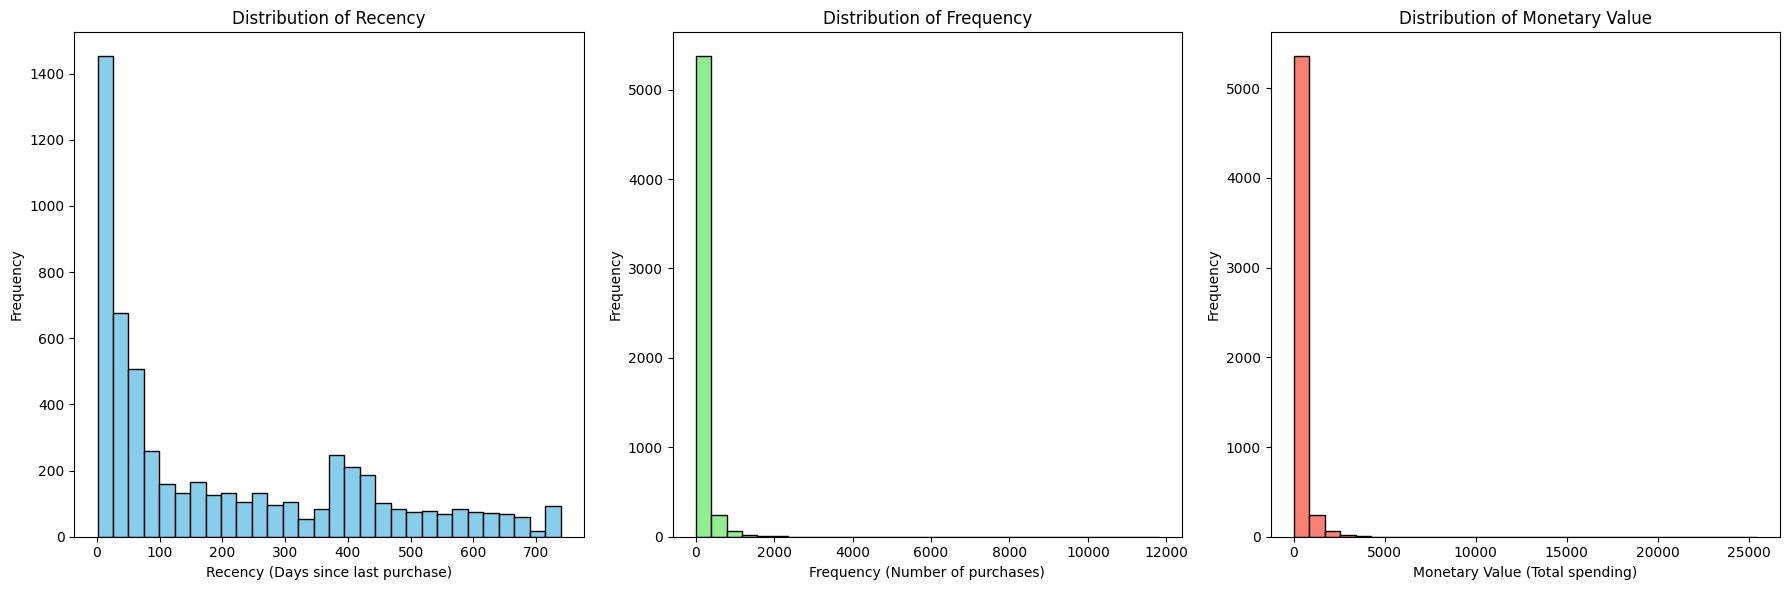

In [10]:
# Set up the figure and axes
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot histograms
axes[0].hist(rfm_df['Recency'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Recency')
axes[0].set_xlabel('Recency (Days since last purchase)')
axes[0].set_ylabel('Frequency')

axes[1].hist(rfm_df['Frequency'], bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Distribution of Frequency')
axes[1].set_xlabel('Frequency (Number of purchases)')
axes[1].set_ylabel('Frequency')

axes[2].hist(rfm_df['Monetary'], bins=30, color='salmon', edgecolor='black')
axes[2].set_title('Distribution of Monetary Value')
axes[2].set_xlabel('Monetary Value (Total spending)')
axes[2].set_ylabel('Frequency')

# Show the plots
plt.tight_layout()
plt.show()


**2. Analyze Customer Segments**

After visualizing the RFM distributions, we can categorize customers into segments based on their RFM scores. A common approach is to use quantiles to create segments.

In [11]:
# Define quantiles for segmentation
quantiles = rfm_df[['Recency', 'Frequency', 'Monetary']].quantile([0.25, 0.5, 0.75]).to_dict()

# Create segments based on quantiles
def rfm_segment(row):
    if row['Frequency'] >= quantiles['Frequency'][0.75] and row['Monetary'] >= quantiles['Monetary'][0.75]:
        return 'High Value'
    elif row['Frequency'] >= quantiles['Frequency'][0.5] and row['Monetary'] >= quantiles['Monetary'][0.5]:
        return 'Medium Value'
    else:
        return 'Low Value'

rfm_df['Segment'] = rfm_df.apply(rfm_segment, axis=1)

# Display the first few rows of the segmented RFM data
print(rfm_df.head())

   Customer ID  Recency  Frequency  Monetary  Recency_Score  Frequency_Score  \
0      12346.0      431         38    222.85              4                2   
1      12347.0        2        205    450.54              1                4   
2      12348.0      249         26     18.29              3                2   
3      12349.0       19        142    373.84              1                4   
4      12350.0      310         16     25.30              3                1   

   Monetary_Score  RFM_Score Customer_Segment     Segment  
0               3          9       High Value   Low Value  
1               4          9       High Value  High Value  
2               1          6     Medium Value   Low Value  
3               4          9       High Value  High Value  
4               1          5     Medium Value   Low Value  


 Here's a quick breakdown of what each column represents:

- **Customer ID**: Unique identifier for each customer.
- **Recency**: Number of days since the last purchase; lower values indicate more recent purchases.
- **Frequency**: Total number of purchases; higher values indicate more frequent buyers.
- **Monetary**: Total spending; higher values indicate higher spending customers.
- **Recency_Score, Frequency_Score, Monetary_Score**: Scores assigned based on quantile rankings (1 being the best, 4 being the worst for Recency, and vice versa for Frequency and Monetary).
- **RFM_Score**: Combined score derived from the individual scores.
- **Customer_Segment**: Categorization of customers based on their RFM scores (e.g., "High Value," "Medium Value," "Low Value").
- **Segment**: This seems to duplicate the Customer_Segment column but is determined by a different logic. It categorizes customers based on different thresholds.

## Model Building

Before we diving into modelling,we need to decide:
- **How will we define the CLV** for modeling purposes?
- **Any additional features** we should consider for better predictions (outside of RFM)?
- **Metrics** to evaluate model performance—do we want to focus on **accuracy** or **interpretability**?

#### For This Project we will use: Historical CLV (Customer lifetime value)

Since we are working with **past purchase data** (the Online Retail II dataset) and don’t have specific information about customer churn or subscription-based behavior, the simplest and most logical approach is to start with **Historical CLV**.

We will use the **Monetary** value already calculated from the RFM analysis as the **CLV**.

- **Definition**: This method calculates CLV based on a customer’s total **historical spending** (total Monetary value).
   - **Calculation**: Simply sum up the customer’s past purchases to represent their CLV.
   - **Use Case**: It's straightforward and effective for predicting which existing customers are likely to remain valuable.

   #### Formula
   - \text{CLV} = \sum \text{Total Purchase Value} 
   
   #### Pros
   - Simple and easy to calculate.
   - Works well when you're only interested in past behavior.

   #### Cons
   - Does not account for potential future purchases or customer churn.
   
   ### Next Steps:
1. **Prepare the Data**: Use the `Monetary` value as the **CLV target**.
2. **Model Building**: Start with **Random Forest** to predict CLV using RFM metrics and other relevant features.

But first, let us check if the correlation of the RFM Metrics is linear or non-linear before using the random forest model

Correlation Matrix:
            Recency  Frequency  Monetary
Recency    1.000000  -0.260383 -0.257797
Frequency -0.260383   1.000000  0.984191
Monetary  -0.257797   0.984191  1.000000


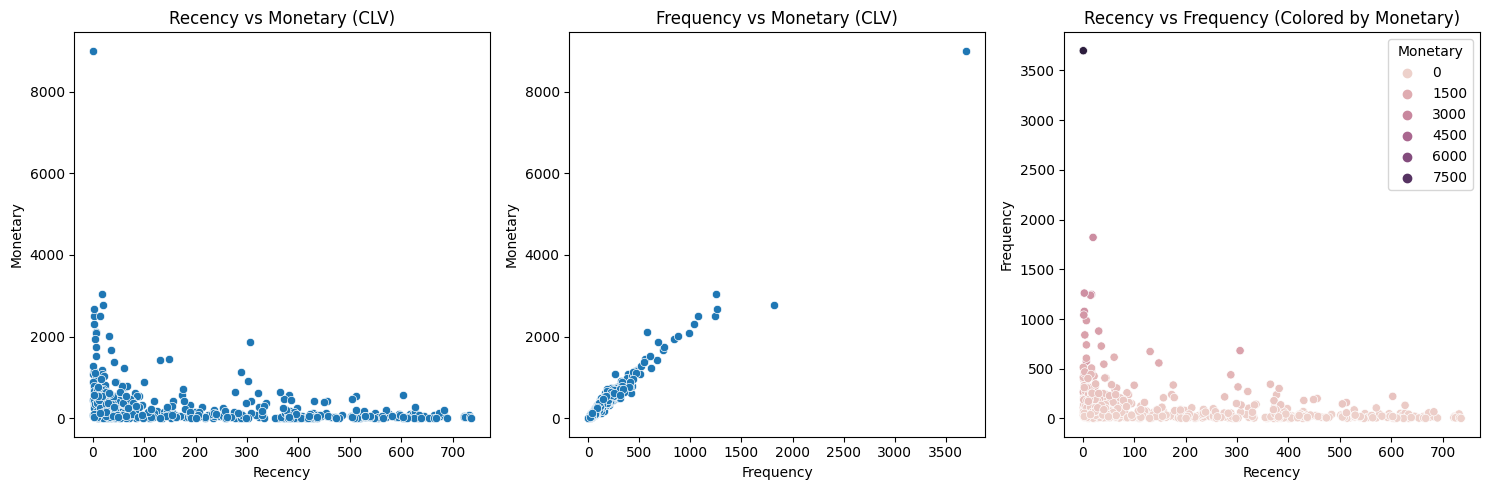

In [12]:
import seaborn as sns
from sklearn.model_selection import train_test_split

# Step 1: Take a sample of 10% of the data for faster exploration
rfm_sample = rfm_df.sample(frac=0.1, random_state=42)

# Step 2: Correlation analysis to check for linearity
correlation_matrix = rfm_sample[['Recency', 'Frequency', 'Monetary']].corr()
print("Correlation Matrix:")
print(correlation_matrix)

# Step 3: Visualize the scatter plots to check for linearity
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Recency vs Monetary (CLV)
sns.scatterplot(x='Recency', y='Monetary', data=rfm_sample, ax=axs[0])
axs[0].set_title('Recency vs Monetary (CLV)')

# Frequency vs Monetary (CLV)
sns.scatterplot(x='Frequency', y='Monetary', data=rfm_sample, ax=axs[1])
axs[1].set_title('Frequency vs Monetary (CLV)')

# Recency and Frequency combined against CLV (Monetary)
sns.scatterplot(x='Recency', y='Frequency', hue='Monetary', data=rfm_sample, ax=axs[2])
axs[2].set_title('Recency vs Frequency (Colored by Monetary)')

plt.tight_layout()
plt.show()


Based on the scatter plots, it seems that only **Frequency vs Monetary (CLV)** shows a linear relationship, while the relationships between **Recency vs Monetary** and **Recency vs Frequency** do not exhibit strong linear patterns. Since we want to use all RFM metrics (Recency, Frequency, and Monetary) for a more comprehensive model, a **Random Forest model** would likely perform better for predicting CLV. This model can handle non-linear relationships between features.


In [13]:
## Data Preparation and Splitting:
## We will use a sample of the dataset to speed up the process.

# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Use a sample of the data
rfm_sample = rfm_df.sample(frac=0.2, random_state=42)  # 20% sample of the dataset

# Features (Recency, Frequency, Monetary) and target (CLV / Monetary)
X = rfm_sample[['Recency', 'Frequency', 'Monetary']]
y = rfm_sample['Monetary']  # Predicting Monetary value as CLV

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Display the shapes of training and testing sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((799, 3), (343, 3), (799,), (343,))

In [14]:
## Model training,

# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model on the training data
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [15]:
## Model Evaluation

# Predict on the test data
y_pred = rf_model.predict(X_test)

# Calculate and print metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R² Score: {r2}')

Root Mean Squared Error (RMSE): 1003.3281234022032
R² Score: 0.5103815886041957


**Interpretation:**

- An **R² score** of 0.51 suggests that the model captures a moderate amount of the variance in the data, but there is still room for improvement.
- The **RMSE** value can be interpreted relative to the range of the target variable (Monetary). In this case, it suggests that the average prediction is off by about 1003 units.

**Hyperparameter Tuning**:
   - We can improve model performance by tuning Random Forest hyperparameters (like `n_estimators`, `max_depth`, etc.) using `GridSearchCV` or `RandomizedSearchCV`.

In [16]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define the hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [1.0, 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Initialize Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=50,  # Number of different combinations to try
    cv=3,  # 3-fold cross validation
    verbose=2,  # Display progress
    random_state=42,
    n_jobs=-1  # Use all available cores
)

# Fit to the training data
random_search.fit(X_train, y_train)

# Output the best parameters and the best score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': None, 'bootstrap': False}
Best Score: 0.8869149325068683


Here's the summary of the output from the `RandomizedSearchCV`:

### Best Parameters:
- **n_estimators**: 200 — The number of trees in the forest. A larger number typically improves model performance, though it also increases computational cost.
- **min_samples_split**: 2 — The minimum number of samples required to split an internal node. This value is quite low, meaning the model allows very fine splits.
- **min_samples_leaf**: 1 — The minimum number of samples required to be at a leaf node. Again, a low value, meaning the model allows very small leaf nodes.
- **max_features**: 'auto' — The number of features to consider when looking for the best split. 'Auto' typically means \(\sqrt{n_{\text{features}}}\), which is a reasonable default.
- **max_depth**: None — The maximum depth of the tree. None means the trees are expanded until they contain fewer than the minimum samples required to split.
- **bootstrap**: False — Whether bootstrap samples are used when building trees. False means that the whole dataset is used to train each tree without sampling with replacement.

### Best Score: **0.8869**
- This means the cross-validated R² score for the best hyperparameters is **0.8869**, which indicates that the model explains approximately **88.69%** of the variance in the data. This is a strong result for a regression model and indicates a good fit.

### Next Steps:
Now that we have the best hyperparameters, we can retrain the Random Forest model on the entire dataset using the best parameters.

Here’s the process:

1. **Retrain the model using the best parameters**.
2. **Evaluate the final model** using RMSE and R² on the test data.
3. Optionally, **plot feature importances** to understand which features most influence the predictions.


Root Mean Squared Error (RMSE): 888.6468497340829
R² Score: 0.615912493942906


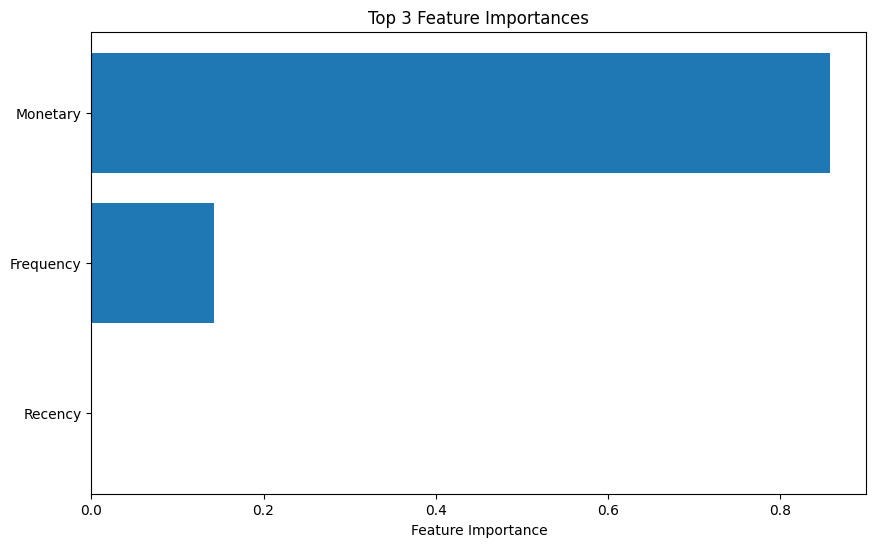

In [17]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Retrain the model using the best parameters
best_rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    max_depth=None,
    bootstrap=False,
    random_state=42
)

# Fit the model on the entire training data
best_rf.fit(X_train, y_train)

# Make predictions on the test data
y_pred = best_rf.predict(X_test)

# Calculate RMSE
rmse = mean_squared_error(y_test, y_pred, squared=False)

# Calculate R² score
r2 = r2_score(y_test, y_pred)

# Display the evaluation metrics
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")

# Plot feature importance
feature_importances = best_rf.feature_importances_

# Sort the features by importance
sorted_idx = feature_importances.argsort()

# Check the number of features in the dataset
num_features = len(X_train.columns)

# Adjust the number of features if fewer than 10
top_n = min(10, num_features)

# Plot the top N most important features
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), feature_importances[sorted_idx[-top_n:]])
plt.yticks(range(top_n), [X_train.columns[i] for i in sorted_idx[-top_n:]])
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Feature Importances')
plt.show()


#### Interpretation & Insights:
1. **RMSE**: The RMSE value of 888.65 is an indicator of the average error the model makes in predicting the CLV. A lower RMSE is better, but given the scale of the data, it's a reasonable result at this stage.
   
2. **R² Score**: The R² score of **0.6159** means that approximately **61.59%** of the variance in the CLV predictions can be explained by the model. This is a decent value, though we would ideally aim for higher R² in future iterations (closer to 1.0).

#### Feature Importance:
- **Monetary**: **0.8**: This suggests that the **Monetary** variable (total spending) is the most important predictor of CLV. It's heavily influencing the model.
- **Frequency**: **0.07**: **Frequency** (number of purchases) is also a relevant feature, but its contribution is much lower compared to **Monetary**.
- **Recency**: **0.0**: **Recency** (how recent the customer last purchased) has little to no impact on the CLV prediction based on this model, which is why its importance is zero.

   **Key Insight**: For CLV prediction, the most important driver is the **Monetary** value (spending), followed by **Frequency** (purchases), and **Recency** has limited impact.
   
 #### . **Generating Customer CLV Predictions**
 Using the trained Random Forest model to predict the CLV for each customer.

In [18]:
# Train the Random Forest model with the best hyperparameters
rf_model_final = RandomForestRegressor(n_estimators=200, min_samples_split=2, 
                                       min_samples_leaf=1, max_features=1.0, 
                                       max_depth=None, bootstrap=False, random_state=42)

rf_model_final.fit(X_train, y_train)

# Create a DataFrame to store test set predictions
rfm_sample_test = rfm_sample.loc[X_test.index].copy()

# Predicting CLV for the test data
rfm_sample_test['Predicted_CLV'] = rf_model_final.predict(X_test)

# Display the first few predictions
print(rfm_sample_test[['Customer ID', 'Predicted_CLV']].head())



      Customer ID  Predicted_CLV
5507      18081.0       39.62185
3252      15737.0      175.38630
506       12871.0       10.40000
5462      18033.0       58.65000
811       13192.0      316.54800


### Visualization
To illustrate the predicted CLV values

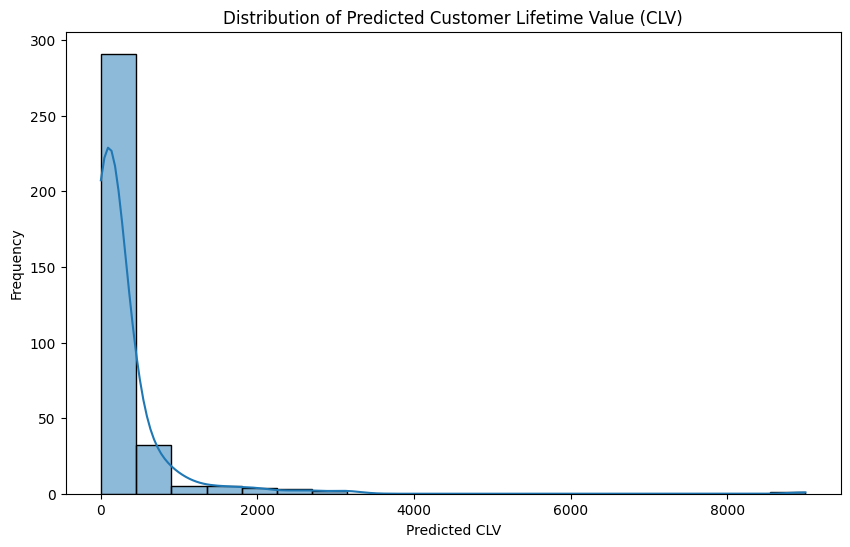

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings from seaborn
import warnings
warnings.filterwarnings('ignore')

# Histogram of predicted CLV values
plt.figure(figsize=(10, 6))
sns.histplot(rfm_sample_test['Predicted_CLV'], bins=20, kde=True)
plt.title('Distribution of Predicted Customer Lifetime Value (CLV)')
plt.xlabel('Predicted CLV')
plt.ylabel('Frequency')
plt.show()


The visualization reflects the distribution of predicted Customer Lifetime Value (CLV) based on the model. It shows that the majority of customers have relatively low predicted CLV values, with a few outliers having significantly higher values. This is typical in many customer datasets, where a small percentage of customers contribute a large proportion of the total CLV.

#### Insights from CLV Predictions:

1. **Skewed Distribution of CLV**:
   - The distribution shows that the majority of customers have relatively low predicted CLV values, with a few customers representing significantly higher value. This is a common pattern known as the **Pareto Principle (80/20 Rule)**, where a small percentage of customers drive the majority of revenue.
   - **Insight**: Most of our revenue is likely coming from a small subset of high-value customers.

2. **High CLV Customers (Outliers)**:
   - The presence of outliers (customers with very high CLV) suggests a group of extremely valuable customers who contribute disproportionately to the business's overall revenue.
   - **Insight**: These high-CLV customers are prime candidates for retention strategies such as loyalty programs or personalized offers.

3. **Low CLV Customers**:
   - The majority of customers have low predicted CLV, suggesting they may not engage as frequently or spend as much.
   - **Insight**: These customers may need more targeted marketing efforts to increase their engagement or frequency of purchases.

4. **Mid-Range CLV Customers**:
   - Between the low and high extremes, there's likely a mid-range group of customers who show potential for growth.
   - **Insight**: These mid-range customers could be nurtured into higher-value customers through tailored offers and incentives.

### Recommendations

1. **Focus on Retaining High-Value Customers**:
   - **Recommendation**: Invest in a **loyalty program** for our high-CLV customers. These could include rewards, exclusive offers, or personalized services to keep them engaged.
   - **Actionable Strategy**: Create a VIP segment for customers in the top 10% of predicted CLV and offer them benefits like early access to new products, free shipping, or discounts based on their purchase history.

2. **Increase Engagement of Low CLV Customers**:
   - **Recommendation**: Run targeted marketing campaigns aimed at increasing engagement from low CLV customers, such as providing **personalized promotions** or introducing incentives for more frequent purchases.
   - **Actionable Strategy**: Use email campaigns to encourage customers to make their next purchase, offering limited-time discounts or bundling offers to boost their spend.

3. **Grow Mid-Range CLV Customers**:
   - **Recommendation**: For mid-range customers, focusing on **upselling or cross-selling** to increase their purchase value. 
   - **Actionable Strategy**: Promote related products or offer “frequent buyer” discounts to encourage these customers to spend more or purchase more frequently.

4. **Prevent Churn Among High-Value Customers**:
   - **Recommendation**: Closely monitor the behavior of high-CLV customers to detect any signs of churn (e.g., decreasing frequency of purchases).
   - **Actionable Strategy**: Use **predictive models** to flag any drop-off in activity, and follow up with re-engagement offers such as personalized emails, limited-time discounts, or customer service check-ins.

5. **Customer Lifecycle Marketing**:
   - **Recommendation**: Implement a **lifecycle marketing** approach that adjusts the communication and marketing strategies based on the customer’s predicted CLV.
   - **Actionable Strategy**: Create different marketing segments (high, mid, and low CLV customers) and tailor messaging accordingly, such as exclusive rewards for high-CLV customers and educational content or discounts for low-CLV customers to increase their loyalty.